<a href="https://colab.research.google.com/github/CookOLo/MAT422/blob/main/HW_2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.4 - Maximum likelihood estimation
## 2.4.1 - MLE for random samples

**Definition 2.4.1.** Let $X_1, X_2, . . ., X_n$ have joint pmf or pdf

$$f(x_1, x_2, . . ., x_n; θ_1, . . ., θ_m)$$

where the parameters $θ_1, . . ., θ_m$ have unknown values. When $x_1, . . ., x_n$ are
the observed sample values and is regarded as a function of $θ_1, . . ., θ_m$,
it is called the likelihood function. The maximum likelihood estimates
(mle’s) $\hat{\theta}_1, . . . , \hat{\theta}_m$ are those values of the $θ_i$’s that maximize the likelihood function, so that

$$f(x_1, . . ., x_n; \hat{\theta}_1, . . . , \hat{\theta}_m) ≥ f(x_1, . . ., x_n; θ_1, . . ., θ_m)$$ for all $$θ_1, . . ., θ_m.$$

When the $X_i$’s are substituted in place of the $x_i$’s, the maximum likelihood estimators result.

## 2.4.2 - Linear Regression

Given input data points $\{(x_i, y_i)\}_{i=1}^{n}$, we seek an affine function to fit the data and each $x_i = (x_{i1}, ...., x_{ip})$. The common approach involves finding coefficients $β_j, j = 1..., p$’s that minimize the criterion

$$\sum^n_{i=1} (y_i − \hat{y}_i )^2,$$

where

$$\hat{y}_i = β_0 + β_1x_{i1} + . . . + β_p x_{ip}$$

Now we wish to discuss it from a probabilistic point of view by the maxi-
mum likelihood estimation. Consider that we have n points, each of which
is drawn in an independent and identically distributed way from the
normal distribution. For a given, $μ$, $σ^2$ , the probability of those n points
being drawn define the likelihood function, which are just the multipli-
cation of n normal probability density functions (pdf) (because they are
independent):

$$\mathscr{P}(μ | y) = ∏^n_{i=1} P_Y (y_i | μ, σ^2) = ∏^n_{i=1} \frac{1}{σ \sqrt{2π}} e^{−\frac{(y_i−μ)^2}{2σ^2}}$$

Now understand that $y$ is a random variable,

$$y_i = \hat{y}_i + ε$$,

where $ε ∼ N (0, σ^2)$. Thus $y_i$ is a normal variable with mean as a linear
function of x and a fixed standard deviation:

$$y_i ∼ N (\hat{y}_i, σ^2).$$

As a result, for each y i, we choose $μ$ in the normal distributions in as

$$μ_i = \hat{y}_i.$$

Hence we derive the maximum likelihood estimate

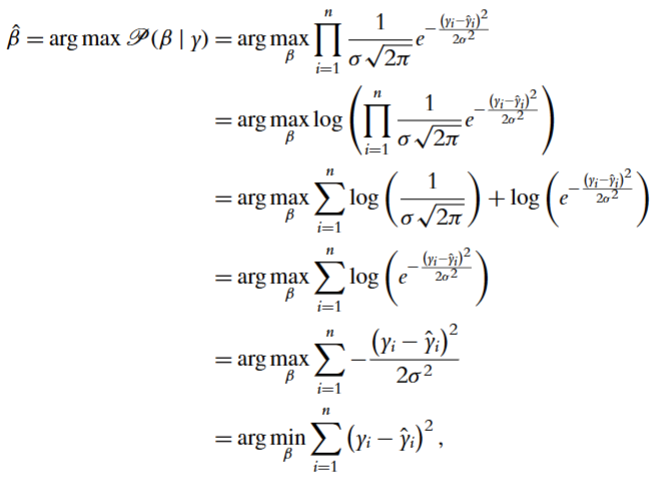

In [4]:
# Imports
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel


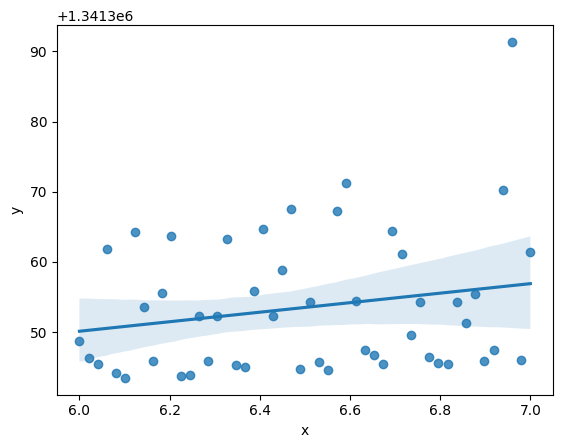

In [12]:
# OLS (orginaly least squares) vs MLE (maximum likelihood estimation) on linear regssion
## Should be near identical as they are mathematical equivalent

### Linear Regression

x = np.linspace(6, 7, 50) # independnet variable
e = np.random.normal(2, 2, 50) # normally distributed residual
y = 3*x + 1341325 + e * e # ground truth
df = pd.DataFrame({'x':x, 'y':y})
df.head()

#### Graphing
sns.regplot(x='x', y='y', data = df)
plt.show()

In [14]:
### Analysis through OLS
df['constant'] = 1
X = df[['constant', 'x']]
sm.OLS(y, X).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     2.131
Date:                Mon, 05 Oct 2026   Prob (F-statistic):              0.151
Time:                        04:20:55   Log-Likelihood:                -183.40
No. Observations:                  50   AIC:                             370.8
Df Residuals:                      48   BIC:                             374.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
constant    1.341e+06     30.228   4.44e+04      0.000    1.34e+06    1.34e+06
x              6.7823      4.646      1.460      0.151      -2.559      16.123
==============================================================================
Omnibus:                       15.619   Durbin-Watson:                   1.873
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.995
Skew:                           1.220   Prob(JB):                     0.000124
Kurtosis:                       4.638   Cond. No.                         147.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
## Analysis through MEL

def mle(p):
  c, b, std = p; # constnat, beta, standard deviation
  pred = c + b*x
  negLL = -np.sum(stats.norm.logpdf(y, pred, std)) # calculate the log-likelihood for normal distrtibution
  return negLL

mle_model = minimize(mle, np.array([4, 4, 4]), method='L-BFGS-B') # minimize arguments

mle_model_df = pd.DataFrame({'coef':mle_model['x']})
mle_model_df.index = ['constant', 'x', 'sigma']
mle_model_df.head(2)



,coef
constant,1.341309e+06
x,6.774830e+00


In [24]:
print("This is very similar to OLS with a ~0.006 difference of x (which is slope coefficient)");

This is very similar to OLS with a ~0.006 difference of x (which is slope coefficient)
